Task 3 - Classification Models
1. Use a dataset (like Titanic) to build a classification model that predicts a categorical target variable (e.g., survived/not survived).

2. Compare at least two classifiers (e.g., Logistic Regression vs Decision Tree).

3. Evaluate your model using a confusion matrix, accuracy, precision, recall, and F1-score.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [7]:
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [8]:
df["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [9]:
df["SibSp"].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [10]:
df["Parch"].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


In [11]:
df["Cabin"].value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [12]:
df["cabin_alphabet"] = df["Cabin"].str[0]
df["cabin_alphabet"].value_counts()

,count
cabin_alphabet,
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [13]:
df.groupby("cabin_alphabet")["Survived"].mean()

,Survived
cabin_alphabet,
A,0.466667
B,0.744681
C,0.593220
D,0.757576
E,0.750000
F,0.615385
G,0.500000
T,0.000000


In [14]:
df.groupby("Embarked")["Survived"].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


<Axes: xlabel='Age', ylabel='Count'>

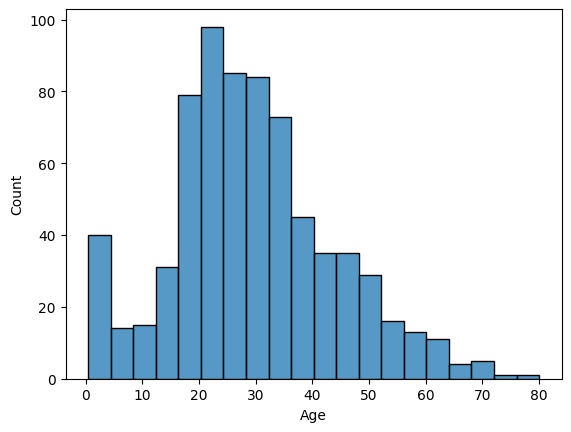

In [15]:
sns.histplot(df["Age"])

<Axes: xlabel='Fare', ylabel='Count'>

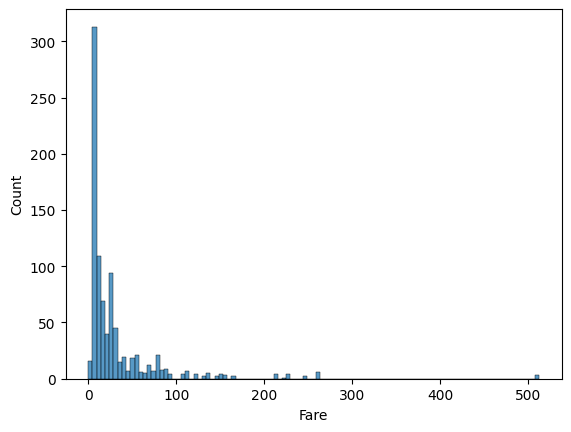

In [16]:
sns.histplot(df["Fare"])

In [17]:
df["Fare_log"] = np.log1p(df["Fare"])

<Axes: xlabel='Fare_log', ylabel='Count'>

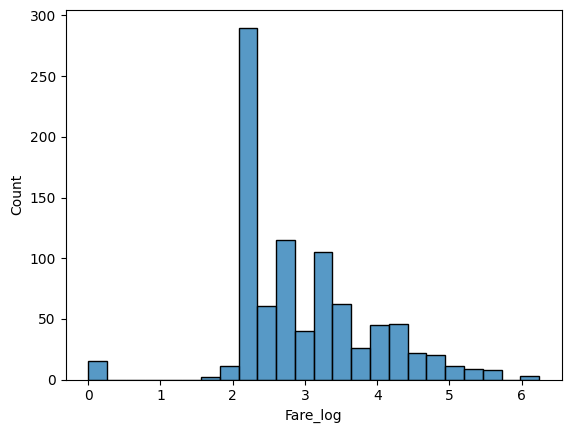

In [18]:
sns.histplot(df["Fare_log"])

In [19]:
# Removing Name and Ticket columns
df_1 = df.drop(columns = ["Name", "Ticket", "Fare", "Cabin"], axis = 1)
df_1

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,cabin_alphabet,Fare_log
0,1,0,3,male,22.0,1,0,S,NaN,2.110213
1,2,1,1,female,38.0,1,0,C,C,4.280593
2,3,1,3,female,26.0,0,0,S,NaN,2.188856
3,4,1,1,female,35.0,1,0,S,C,3.990834
4,5,0,3,male,35.0,0,0,S,NaN,2.202765
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,S,NaN,2.639057
887,888,1,1,female,19.0,0,0,S,B,3.433987
888,889,0,3,female,NaN,1,2,S,NaN,3.196630
889,890,1,1,male,26.0,0,0,C,C,3.433987


In [20]:
# applying ordinal encoding to object columns
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output = False, drop=None)
encoded = ohe.fit_transform(df_1[["Sex", "cabin_alphabet", "Embarked"]])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["Sex", "cabin_alphabet", "Embarked"])
)

In [21]:
df_final = pd.concat([df_1.drop(["Sex", "cabin_alphabet", "Embarked"], axis=1), encoded_df], axis=1)

In [32]:
df_final

,Survived,Pclass,Age,SibSp,Parch,Fare_log,Sex_female,Sex_male,cabin_alphabet_A,cabin_alphabet_B,...,cabin_alphabet_D,cabin_alphabet_E,cabin_alphabet_F,cabin_alphabet_G,cabin_alphabet_T,cabin_alphabet_nan,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,0,3,22.0,1,0,2.110213,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1,1,38.0,1,0,4.280593,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,3,26.0,0,0,2.188856,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1,1,35.0,1,0,3.990834,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,3,35.0,0,0,2.202765,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,2.639057,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
887,1,1,19.0,0,0,3.433987,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
888,0,3,NaN,1,2,3.196630,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
889,1,1,26.0,0,0,3.433987,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [30]:
df_final.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare_log', 'Sex_female',
       'Sex_male', 'cabin_alphabet_A', 'cabin_alphabet_B', 'cabin_alphabet_C',
       'cabin_alphabet_D', 'cabin_alphabet_E', 'cabin_alphabet_F',
       'cabin_alphabet_G', 'cabin_alphabet_T', 'cabin_alphabet_nan',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Embarked_nan'],
      dtype='object')

In [33]:
df_final = df_final.drop([ "cabin_alphabet_nan",'Embarked_nan'] , axis =1)

In [35]:
df_final.fillna(0)

,Survived,Pclass,Age,SibSp,Parch,Fare_log,Sex_female,Sex_male,cabin_alphabet_A,cabin_alphabet_B,cabin_alphabet_C,cabin_alphabet_D,cabin_alphabet_E,cabin_alphabet_F,cabin_alphabet_G,cabin_alphabet_T,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,2.110213,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,1,38.0,1,0,4.280593,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,3,26.0,0,0,2.188856,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,1,35.0,1,0,3.990834,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,3,35.0,0,0,2.202765,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,2.639057,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
887,1,1,19.0,0,0,3.433987,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
888,0,3,0.0,1,2,3.196630,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
889,1,1,26.0,0,0,3.433987,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [62]:
## capping it with IQR
df_capped = df_final.copy()
for col in ["Age", "Fare_log"]:
    Q1 = df[col].quantile(0.15)
    Q3 = df[col].quantile(0.85)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df_capped[col] = np.where(df_final[col] > upper, upper,
                       np.where(df_final[col] < lower, lower, df_final[col]))

In [63]:
df_capped.isnull().sum()

,0
Survived,0
Pclass,0
Age,177
SibSp,0
Parch,0
Fare_log,0
Sex_female,0
Sex_male,0
cabin_alphabet_A,0
cabin_alphabet_B,0


In [64]:
df_capped["Age"] = df_capped["Age"].fillna(df_capped["Age"].mean())

In [65]:
df_capped

,Survived,Pclass,Age,SibSp,Parch,Fare_log,Sex_female,Sex_male,cabin_alphabet_A,cabin_alphabet_B,cabin_alphabet_C,cabin_alphabet_D,cabin_alphabet_E,cabin_alphabet_F,cabin_alphabet_G,cabin_alphabet_T,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,2.110213,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,1,38.000000,1,0,4.280593,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,3,26.000000,0,0,2.188856,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,1,35.000000,1,0,3.990834,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,3,35.000000,0,0,2.202765,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,2.639057,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
887,1,1,19.000000,0,0,3.433987,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
888,0,3,29.699118,1,2,3.196630,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
889,1,1,26.000000,0,0,3.433987,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [66]:
X = df_capped.drop('Survived', axis=1)
y = df_capped['Survived']

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((668, 18), (223, 18), (668,), (223,))

In [68]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

## Only scale continuous numeric features, not one-hot encoded features.

In [69]:
binary_cols = [col for col in X_train.columns if set(X_train[col].unique()) <= {0, 1}]
num_cols = [col for col in X_train.select_dtypes(include=['int64', 'float64']).columns
            if col not in binary_cols]

In [70]:
num_cols

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare_log']

In [71]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

Text(0.5, 1.0, 'X_train After scaling')

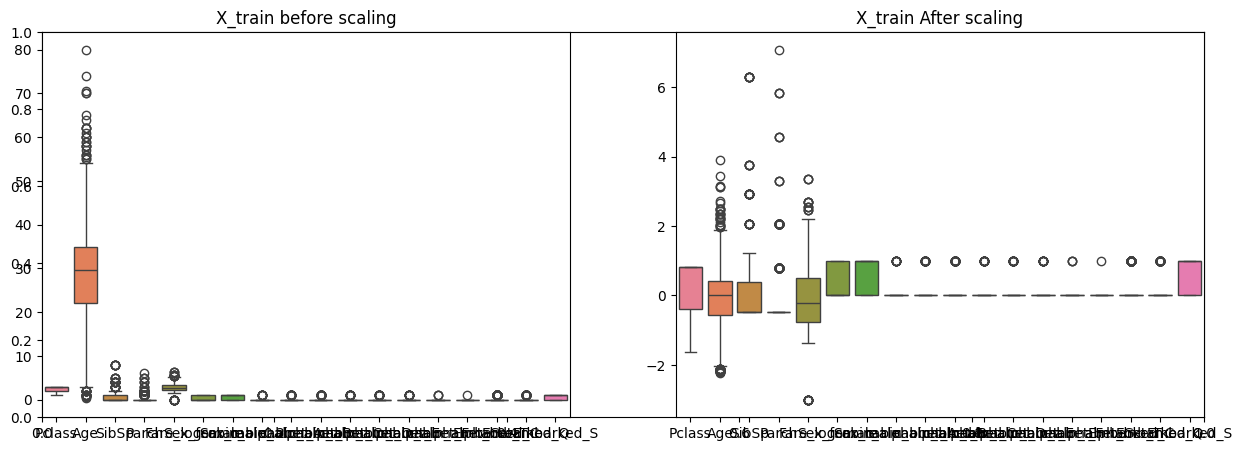

In [72]:
plt.subplots(figsize = (15,5))
plt.subplot(1,2,1)
sns.boxplot(X_train)
plt.title("X_train before scaling")
plt.subplot(1,2,2)
sns.boxplot(X_train_scaled)
plt.title("X_train After scaling")

In [73]:
X_train_scaled

,Pclass,Age,SibSp,Parch,Fare_log,Sex_female,Sex_male,cabin_alphabet_A,cabin_alphabet_B,cabin_alphabet_C,cabin_alphabet_D,cabin_alphabet_E,cabin_alphabet_F,cabin_alphabet_G,cabin_alphabet_T,Embarked_C,Embarked_Q,Embarked_S
298,-1.620517,0.017145,-0.467660,-0.468878,0.514139,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
884,0.809349,-0.344320,-0.467660,-0.468878,-0.876448,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
247,-0.405584,-0.421242,-0.467660,2.046870,-0.208664,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
478,0.809349,-0.575085,-0.467660,-0.468878,-0.818515,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
305,-1.620517,-2.196596,0.376656,2.046870,2.122020,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.809349,-0.652007,-0.467660,-0.468878,-0.803177,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
270,-1.620517,0.017145,-0.467660,-0.468878,0.530190,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
860,0.809349,0.886429,1.220971,-0.468878,-0.234753,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
435,-1.620517,-1.190459,0.376656,2.046870,1.885856,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test_log = log_reg.predict(X_test_scaled)

### 2. Compare at least two classifiers (e.g., Logistic Regression vs Decision Tree).

In [75]:
log_reg_train_acc = accuracy_score(y_train, y_pred_train)
log_reg_test_acc = accuracy_score(y_test, y_pred_test)

In [76]:
log_reg_train_acc, log_reg_test_acc

(0.8068862275449101, 0.8026905829596412)

In [86]:
# Decvision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth = 3, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_train = dt.predict(X_train_scaled)
y_pred_test_dt = dt.predict(X_test_scaled)

In [82]:
dt_train_acc = accuracy_score(y_train, y_pred_train)
dt_test_acc = accuracy_score(y_test, y_pred_test)

In [83]:
dt_train_acc, dt_test_acc

(0.8323353293413174, 0.8026905829596412)


### 3. Evaluate your model using a confusion matrix, accuracy, precision, recall, and F1-score.

In [84]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n🔹 {model_name} Evaluation Metrics")
    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print("Confusion Matrix:\n", cm)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    # Heatmap visualization
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()



🔹 Logistic Regression Evaluation Metrics
Confusion Matrix:
 [[114  20]
 [ 24  65]]
Accuracy:  0.8027
Precision: 0.8016
Recall:    0.8027
F1-score:  0.8019


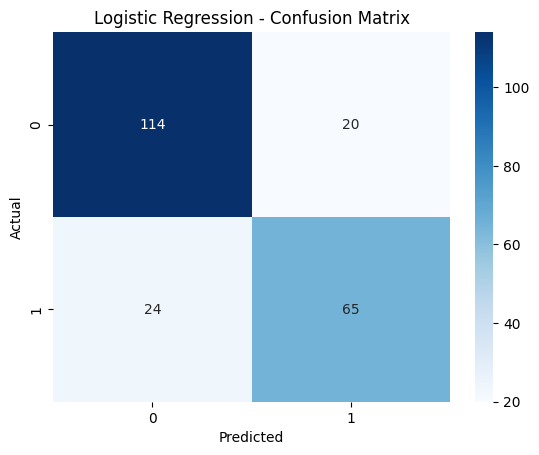


🔹 Decision Tree Evaluation Metrics
Confusion Matrix:
 [[117  17]
 [ 27  62]]
Accuracy:  0.8027
Precision: 0.8014
Recall:    0.8027
F1-score:  0.8004


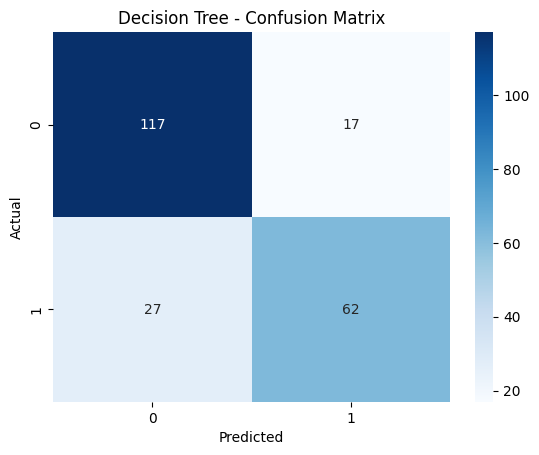

In [87]:
evaluate_model(y_test, y_pred_test_log, "Logistic Regression")
evaluate_model(y_test, y_pred_test_dt, "Decision Tree")